In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h1>Retail Shopping Behavior Analysis</h1>

In this notebook we will be using the Shopping behavior dataset to explore purchasing behavior of customers based on their attributes.
The data consists of multiple purchases and their correlation with various parameters such as age, gender, category

In [149]:
#Load retail dataset 
df = pd.read_csv('shopping_behavior_updated.csv') 


#Data cleaning remove null values
df.dropna(subset=['Purchase Amount (USD)', 'Gender', 'Age', 'Category', 'Item Purchased'], inplace=True)


In [150]:
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [151]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [152]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


In [153]:
df.keys()

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [154]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


<h1>Insights on the customer</h1>

The average age of the customer is 44 with the range being from 18 to 70 years old

A customer spend an average of 60\\$ in the shop with minimum spend being 20$ and max being 100

<h1> Checking unique values</h1>

checking in each column to determine dimensions and fact

The dimensions column giving more informations about the customer are :

Age > age of the customer

Gender > the gneder of the customer


The ones providing us more detail about the item purchased are :

Color > color of the item

Size > size of the item 

Category > if the item is a clothing, accessories or anything else

Item purchased > a sub category of item like Scarf(accessories), Shirt(Clothing), Shoes(footwear), etc


The one providing payment behaviour of customers are:

Shipping type > how the product will be delivered to the custmers after purchase

Payment Method > if the customer is pay by card, cash, etc

Subsribtion status > is the customer subscribed to the shop to avail discounts and promotions

Discount Applied > if the discount code is applied while purchasing

Promo code used > if the Promo code is used while purchasing



In [155]:
columns = [
    "Customer ID", "Age", "Gender", "Size", "Color", "Category", "Item Purchased", 
     "Location", "Season", "Shipping Type", "Payment Method", "Frequency of Purchases", 
    "Subscription Status", "Discount Applied", "Promo Code Used", 
    "Purchase Amount (USD)", "Previous Purchases", "Review Rating"
]

for col in columns:
    if col in df.columns:
        print(f"\n===== {col} =====")
        print(df[col].unique())
    else:
        print(f"\n[WARNING] Column not found: {col}")


===== Customer ID =====
[   1    2    3 ... 3898 3899 3900]

===== Age =====
[55 19 50 21 45 46 63 27 26 57 53 30 61 65 64 25 52 66 31 56 18 38 54 33
 36 35 29 70 69 67 20 39 42 68 49 59 47 40 41 48 22 24 44 37 58 32 62 51
 28 43 34 23 60]

===== Gender =====
['Male' 'Female']

===== Size =====
['L' 'S' 'M' 'XL']

===== Color =====
['Gray' 'Maroon' 'Turquoise' 'White' 'Charcoal' 'Silver' 'Pink' 'Purple'
 'Olive' 'Gold' 'Violet' 'Teal' 'Lavender' 'Black' 'Green' 'Peach' 'Red'
 'Cyan' 'Brown' 'Beige' 'Orange' 'Indigo' 'Yellow' 'Magenta' 'Blue']

===== Category =====
['Clothing' 'Footwear' 'Outerwear' 'Accessories']

===== Item Purchased =====
['Blouse' 'Sweater' 'Jeans' 'Sandals' 'Sneakers' 'Shirt' 'Shorts' 'Coat'
 'Handbag' 'Shoes' 'Dress' 'Skirt' 'Sunglasses' 'Pants' 'Jacket' 'Hoodie'
 'Jewelry' 'T-shirt' 'Scarf' 'Hat' 'Socks' 'Backpack' 'Belt' 'Boots'
 'Gloves']

===== Location =====
['Kentucky' 'Maine' 'Massachusetts' 'Rhode Island' 'Oregon' 'Wyoming'
 'Montana' 'Louisiana' 'West Vi

<h1>Revenue by Gender</h1>

In the dataset, Females have spend around 80k while males have spend alomost doube at around 160k

Now checking by adding another dimension of Category to the graph
Surprisingly in the dataset, male gender is spending almost double in each category in comparison to females

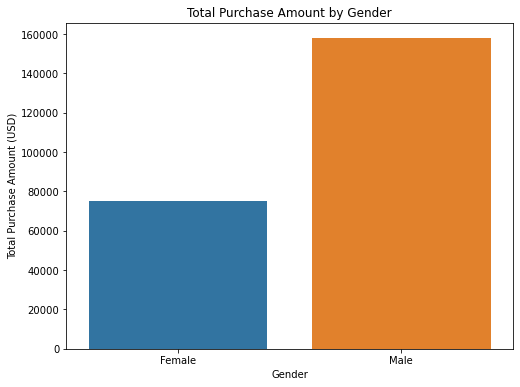

In [156]:
#create Gender datafrome by grouping it
gender_purchase = df.groupby('Gender')['Purchase Amount (USD)'].sum().reset_index()

#Revenue by gender
plt.figure(figsize=(8,6))
sns.barplot(data=gender_purchase, 
            x='Gender', 
            y='Purchase Amount (USD)'
           )

plt.title('Total Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Purchase Amount (USD)')
plt.show()

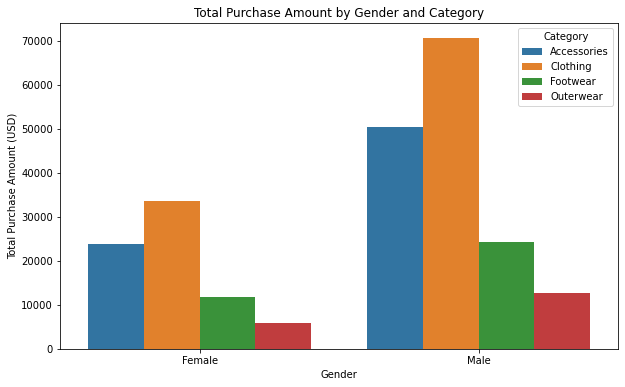

In [157]:
#Create grouped dataframe by Gender and Category
gender_category_purchase = (
    df.groupby(['Gender', 'Category'])['Purchase Amount (USD)']
      .sum()
      .reset_index()
)

#Revenue by gender and category
plt.figure(figsize=(10,6))
sns.barplot(
    data=gender_category_purchase,
    x='Gender',
    y='Purchase Amount (USD)',
    hue='Category'   
)

plt.title('Total Purchase Amount by Gender and Category')
plt.xlabel('Gender')
plt.ylabel('Total Purchase Amount (USD)')
plt.legend(title='Category')
plt.show()

<h1>Revenue by Age</h1>

The age group of 46 to 60 makes the most spend of almost 70k, 

Now checking it with respect to genders as well to get more granularity, 
The purchasing trend shown is quite similar white women and men of age 46 to 60 spend the most with around 30k and 40k respectively

In [158]:
#The age of customer has many unqiue values make it diffcult to analyse, so creating age groups to make analysis manageble
bins = [18, 25, 35, 45, 60, 100]
labels = ['18-25', '26-35', '36-45', '46-60', '60+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
age_purchase = df.groupby('Age Group')['Purchase Amount (USD)'].sum().reset_index()


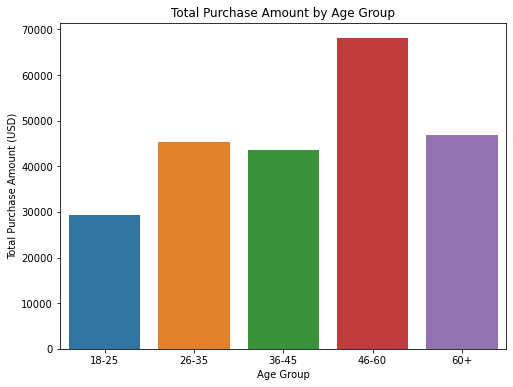

In [159]:
#Revenue by age grorp graph
plt.figure(figsize=(8,6))
sns.barplot(data=age_purchase, 
            x='Age Group', 
            y='Purchase Amount (USD)'
           )

plt.title('Total Purchase Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Purchase Amount (USD)')
plt.show()

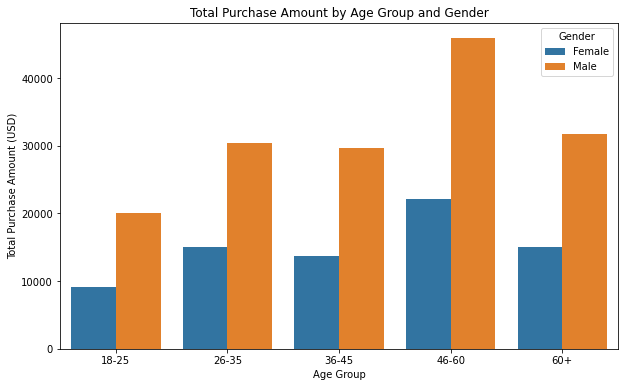

In [160]:
#Create grouped dataframe by Age Group and Gender
age_gender_purchase = (
    df.groupby(['Age Group', 'Gender'])['Purchase Amount (USD)']
      .sum()
      .reset_index()
)

#Revenue by gender and age group
plt.figure(figsize=(10,6))
sns.barplot(
    data=age_gender_purchase,
    x='Age Group',
    y='Purchase Amount (USD)',
    hue='Gender'      
)

plt.title('Total Purchase Amount by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Total Purchase Amount (USD)')
plt.legend(title='Gender')
plt.show()


<h1>Revenue in each category by Age</h1>

the customer that are between 46 and 60 years of age spend the most in each category

The most customers spend on is clothing followed by accessories based on clothing.
Then comes footwear and lastly Outerwear

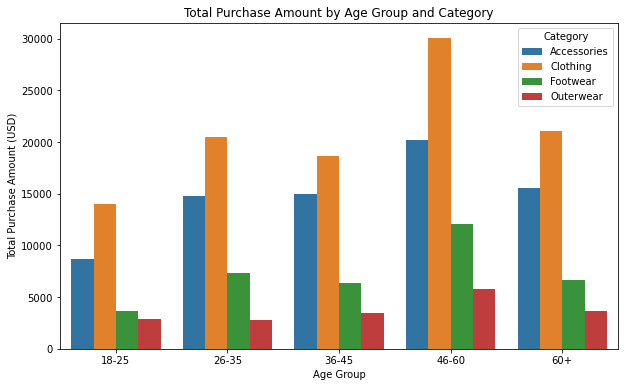

In [161]:
#Create grouped dataframe by Age Group and Category
age_category_purchase = (
    df.groupby(['Age Group', 'Category'])['Purchase Amount (USD)']
      .sum()
      .reset_index()
)

#Revenue by age group and category
plt.figure(figsize=(10,6))
sns.barplot(
    data=age_category_purchase,
    x='Age Group',
    y='Purchase Amount (USD)',
    hue='Category'    
)

plt.title('Total Purchase Amount by Age Group and Category')
plt.xlabel('Age Group')
plt.ylabel('Total Purchase Amount (USD)')
plt.legend(title='Category')
plt.show()

<h1>Revenue generated by Clothing Category</h1>

lets dvelve deeper into the Category with most revenue - clothing, to understand the trend

There are too many sub categries in Clothing, so lets focus on the top 3 most bought clothing items

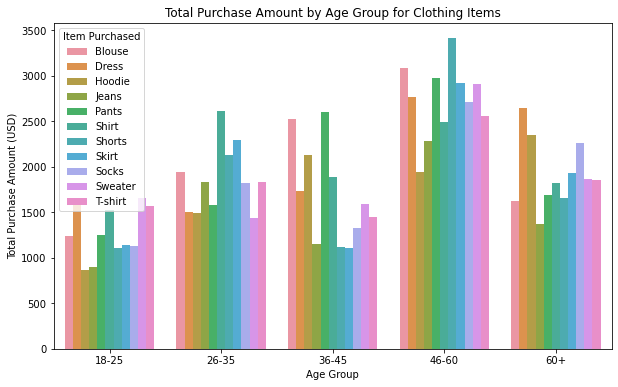

In [162]:
#Filter by Category = Clothing
df_clothing = df[df['Category'] == 'Clothing']

#Create grouped dataframe by Age Group and Item Purchased
age_item_purchase = (
    df_clothing.groupby(['Age Group', 'Item Purchased'])['Purchase Amount (USD)']
        .sum()
        .reset_index()
)

#Revenue by age group for clothing items 
plt.figure(figsize=(10,6))
sns.barplot(
    data=age_item_purchase,
    x='Age Group',
    y='Purchase Amount (USD)',
    hue='Item Purchased'    
)

plt.title('Total Purchase Amount by Age Group for Clothing Items')
plt.xlabel('Age Group')
plt.ylabel('Total Purchase Amount (USD)')
plt.legend(title='Item Purchased')
plt.show()


<h1>Revenue for Shirt, dress and Blouse cloting Items</h1>

The top 3 most bought clothing items are Shirt, Dress and Blouse.

The customer that are 26 to 35 year old or 46 to 60 years old spend most on Shirts

Most Blouse are purchased by cusotmer that are between 36 to 60 years old,

While the dress ins purchased the most by customer that are more than 46 years old



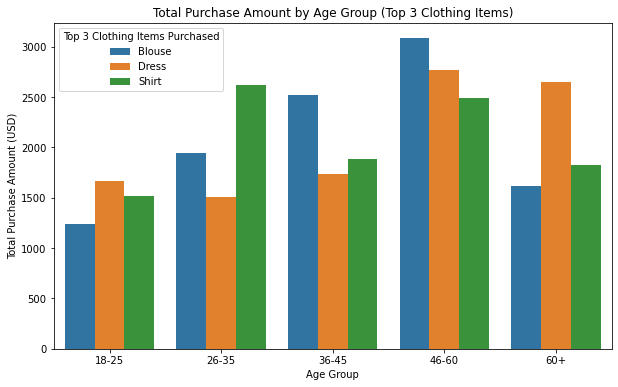

In [163]:
#Find Top 3 items purchased within Clothing by revenue
top_items = (
    df_clothing.groupby('Item Purchased')['Purchase Amount (USD)']
               .sum()
               .sort_values(ascending=False)
               .head(3)
               .index
)

#Keep only rows with these top 3 items
df_top_items = df_clothing[df_clothing['Item Purchased'].isin(top_items)]

#Group by Age Group and Item Purchased
age_item_purchase = (
    df_top_items.groupby(['Age Group', 'Item Purchased'])['Purchase Amount (USD)']
                .sum()
                .reset_index()
)

#Revenue by Age group and top 3 Clothing item
plt.figure(figsize=(10,6))
sns.barplot(
    data=age_item_purchase,
    x='Age Group',
    y='Purchase Amount (USD)',
    hue='Item Purchased'   
)

plt.title('Total Purchase Amount by Age Group (Top 3 Clothing Items)')
plt.xlabel('Age Group')
plt.ylabel('Total Purchase Amount (USD)')
plt.legend(title='Top 3 Clothing Items Purchased')
plt.show()


<h1>Revenue by size of Items</h1>

Now checking the size of clothing purchase, the highest is medium size clothing followed by Large, small and lastly XL

When checking the sale the revenue seems to be similar
adding more dimensions to the data to check if even the revenue is similar, is there any difference to item purchased in each seaosn?

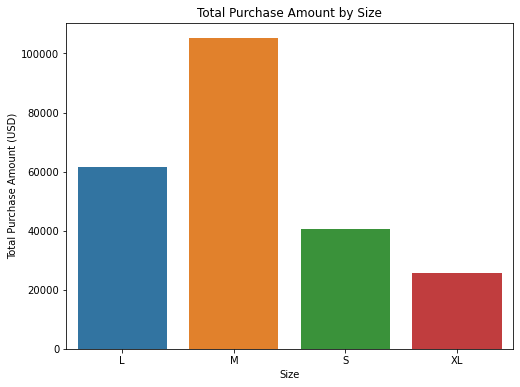

In [164]:
#Create grouped dataframe by size
size_purchase = df.groupby('Size')['Purchase Amount (USD)'].sum().reset_index()

#Revenue by Size
plt.figure(figsize=(8,6))
sns.barplot(data=size_purchase, x='Size', y='Purchase Amount (USD)')
plt.title('Total Purchase Amount by Size')
plt.xlabel('Size')
plt.ylabel('Total Purchase Amount (USD)')
plt.show()

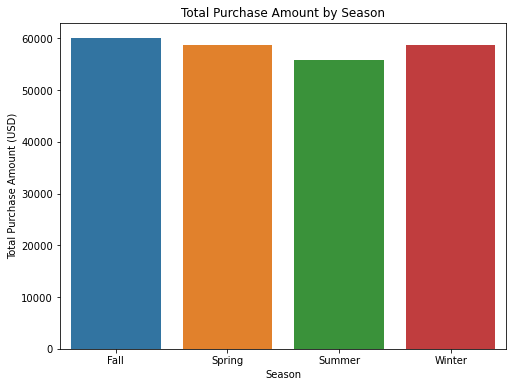

In [165]:
#Create grouped dataframe by season
season_purchase = df.groupby('Season')['Purchase Amount (USD)'].sum().reset_index()

#Revenue by Season
plt.figure(figsize=(8,6))
sns.barplot(data=season_purchase, x='Season', y='Purchase Amount (USD)')
plt.title('Total Purchase Amount by Season')
plt.xlabel('Season')
plt.ylabel('Total Purchase Amount (USD)')
plt.show()

<h1>Revenue by Seasons</h1>


Now checking the size of clothing purchase, the highest is medium size clothing followed by Large, small and lastly XL

When checking the sales, the revenue seems to be similar
adding more dimensions to the data to check if even the revenue is similar, is there any difference to item purchased in each seaosn?

So in Fall the top 3 items purchased are Handbag, Hat and Jacket; which is understandable since its gets quite cold in fall

In Spring, Sweater, Skirt and  blouse top the charts witht the weather warming up

Summer season is dominated by Jewelry, Pants and shoes as people plan their trip and vacation around this time

In winter, the most sold items are Pants, Shirt and Sunglasses, 
which seems odd considering the limited amout of sunlight received in the winter

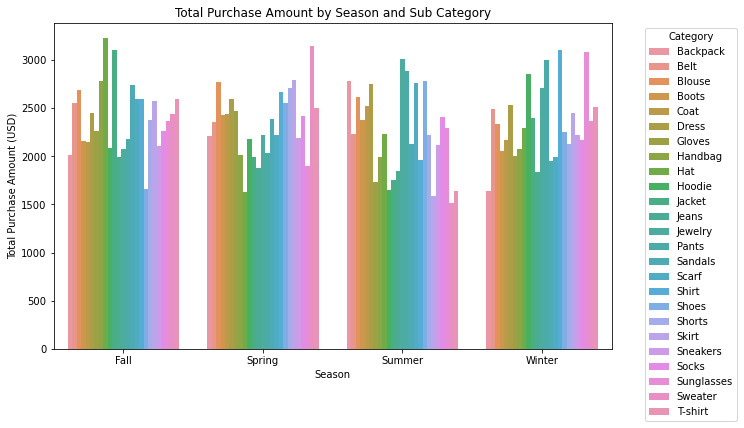

In [166]:
#Create grouped dataframe by Season and sub Category
season_category_purchase = (
    df.groupby(['Season', 'Item Purchased'])['Purchase Amount (USD)']
      .sum()
      .reset_index()
)

#revenue by season and sub category
plt.figure(figsize=(10,6))
sns.barplot(
    data=season_category_purchase,
    x='Season',
    y='Purchase Amount (USD)',
    hue='Item Purchased'   
)

plt.title('Total Purchase Amount by Season and Sub Category')
plt.xlabel('Season')
plt.ylabel('Total Purchase Amount (USD)')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

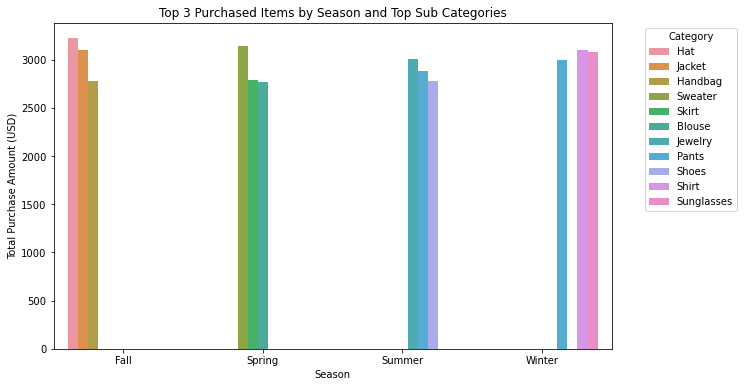

In [167]:
# Get top 3 items per season
top_items_per_season = (
    df.groupby(['Season', 'Item Purchased'])['Purchase Amount (USD)']
      .sum()
      .reset_index()
      .sort_values(['Season', 'Purchase Amount (USD)'], ascending=[True, False])
)

#Keep only top 3 for each season
top3_per_season = (
    top_items_per_season.groupby('Season')
    .head(3)
)

#Revenue by Season and top 3 Item
plt.figure(figsize=(10,6))
sns.barplot(
    data=top3_per_season,
    x='Season',
    y='Purchase Amount (USD)',
    hue='Item Purchased'
)

plt.title('Top 3 Purchased Items by Season and Top Sub Categories')
plt.xlabel('Season')
plt.ylabel('Total Purchase Amount (USD)')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

<h1>Revenue by Shipping methods</h1>

With advent of amazon and other retail giants lets see if the there is any change in shipping behaviour of people

Looking at the chart, it seems like in contrast to popular belief all the shipping option are equally ustilzed

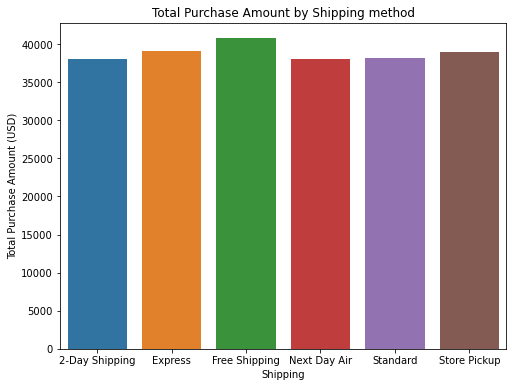

In [168]:
#Create grouped dataframe by shipping method
shipping_purchase = df.groupby('Shipping Type')['Purchase Amount (USD)'].sum().reset_index()

#Revenue by Shipping Method
plt.figure(figsize=(8,6))
sns.barplot(data=shipping_purchase, 
            x='Shipping Type', 
            y='Purchase Amount (USD)')
plt.title('Total Purchase Amount by Shipping method')
plt.xlabel('Shipping')
plt.ylabel('Total Purchase Amount (USD)')
plt.show()


In [170]:
from IPython.display import HTML


HTML('''<h1>Revenue by Payment Method</h1>

all payment methods are used in same amount with revenue, average spend amd number of time a particualr payment method is used reamins quite similar''')



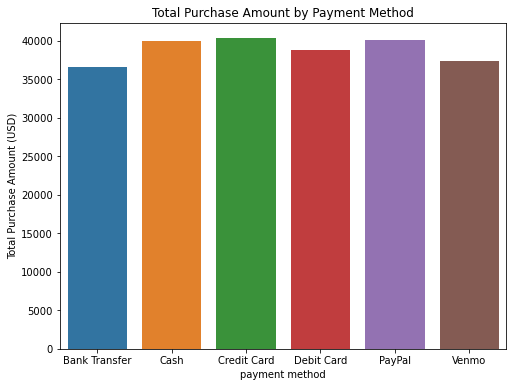

In [145]:
#Create grouped dataframe by Payment Method
payment_method_purchase = df.groupby('Payment Method')['Purchase Amount (USD)'].sum().reset_index()

#Revenue by Payment Method
plt.figure(figsize=(8,6))
sns.barplot(data=payment_method_purchase, x='Payment Method', y='Purchase Amount (USD)')
plt.title('Total Purchase Amount by Payment Method')
plt.xlabel('payment method')
plt.ylabel('Total Purchase Amount (USD)')
plt.show()

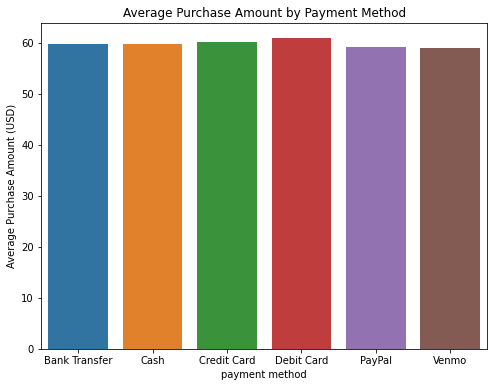

In [146]:
#Create grouped dataframe by Payment Method
payment_method_purchase = df.groupby('Payment Method')['Purchase Amount (USD)'].mean().reset_index()

#Average Revenue by Payment Method
plt.figure(figsize=(8,6))
sns.barplot(data=payment_method_purchase, x='Payment Method', y='Purchase Amount (USD)')
plt.title('Average Purchase Amount by Payment Method')
plt.xlabel('payment method')
plt.ylabel('Average Purchase Amount (USD)')
plt.show()

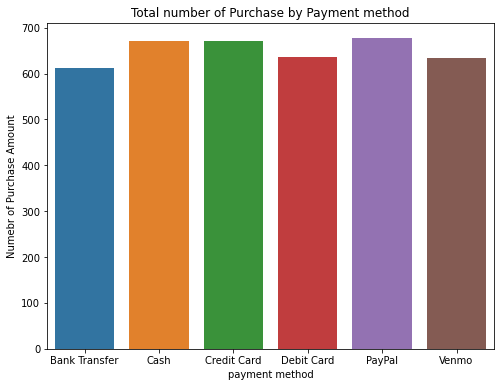

In [147]:
#Create grouped dataframe by Payment Method
payment_method_purchase = df.groupby('Payment Method')['Purchase Amount (USD)'].count().reset_index()

#Number of Purchases by Payment Method
plt.figure(figsize=(8,6))
sns.barplot(data=payment_method_purchase, x='Payment Method', y='Purchase Amount (USD)')
plt.title('Total number of Purchase by Payment method')
plt.xlabel('payment method')
plt.ylabel('Number of Purchase Amount')
plt.show()

<h1>Revenue by Subscription, Discount and Promo Code</h1>

Lets see if people buying have subscribtion with the store or not

It seems like most people dont have a subscription to avail any discounts or promocode, which reflects in the below graphs as well.

This could be used as an opportunity to pitch the usefulness of subscribing to the users and create acampiagn around it 

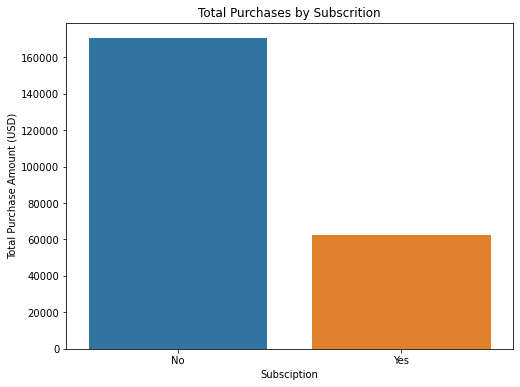

In [171]:
#Create grouped dataframe by Subscription Status
subscription_purchase = df.groupby('Subscription Status')['Purchase Amount (USD)'].sum().reset_index()

#Revenue by Subscription
plt.figure(figsize=(8,6))
sns.barplot(data=subscription_purchase, x='Subscription Status', y='Purchase Amount (USD)')
plt.title('Total Purchases by Subscrition')
plt.xlabel('Subsciption')
plt.ylabel('Total Purchase Amount (USD)')
plt.show()

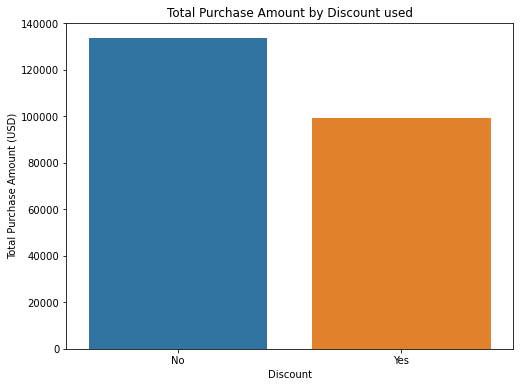

In [172]:
#Create grouped dataframe by Discount Applied
discount_purchase = df.groupby('Discount Applied')['Purchase Amount (USD)'].sum().reset_index()

#Revenue by Discount used
plt.figure(figsize=(8,6))
sns.barplot(data=discount_purchase, x='Discount Applied', y='Purchase Amount (USD)')
plt.title('Total Purchase Amount by Discount used')
plt.xlabel('Discount')
plt.ylabel('Total Purchase Amount (USD)')
plt.show()


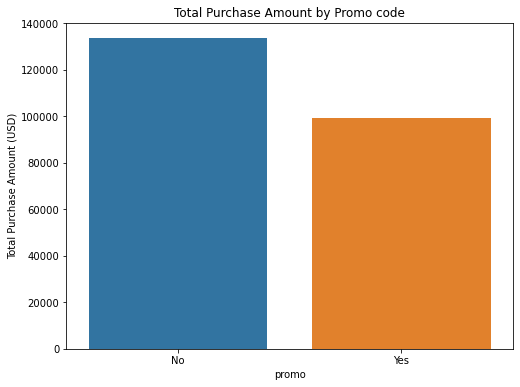

In [173]:

#Create grouped dataframe by Promo Code Used
promo_purchase = df.groupby('Promo Code Used')['Purchase Amount (USD)'].sum().reset_index()

#Revenue by promocode used
plt.figure(figsize=(8,6))
sns.barplot(data=promo_purchase, x='Promo Code Used', y='Purchase Amount (USD)')
plt.title('Total Purchase Amount by Promo code')
plt.xlabel('promo')
plt.ylabel('Total Purchase Amount (USD)')
plt.show()

In [185]:
HTML("""
<h1>Conclusion</h1>
<h2>Customer Demographics</h2>
The Customers who tend to spend the most are Adults aged 46 to 60, with men contributiong alomost double across all categories.

<h2>Ease of Shopping</h2>
Despite Popular belief the factors like Shipping and Payment options have minimal impact on purchasing behavior

<h2>Customer Loyalty</h2>
Lastly, very few customers are currently engaging with Promotions and Subscribtion based discounts

<h2>Seasonal Trends</h2>

<p>Top revenue generating items each season</p>

<p>Fall: Handbags, Hats, Jackets</p>

<p>Spring: Sweaters, Skirts, Blouses</p>

<p>Summer: Jewelry, Pants, Shoes</p>

<p>Winter: Pants, Shirts, Sunglasses (anomaly)</p>

""")